In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print("Setir ve sutun sayi:", df.shape)
print("\nSutunlarin veri tipleri:")
print(df.dtypes)
print("\nItkin (bos) deyerlerin sayi:")
print(df.isnull().sum())

df.head()

Setir ve sutun sayi: (9994, 21)

Sutunlarin veri tipleri:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Itkin (bos) deyerlerin sayi:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount    

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['gonderilme_gunu'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'gonderilme_gunu']].head())
print("\nOrtalama gonderilme muddeti:", df['gonderilme_gunu'].mean(), "gun")

  Order Date  Ship Date  gonderilme_gunu
0 2016-11-08 2016-11-11                3
1 2016-11-08 2016-11-11                3
2 2016-06-12 2016-06-16                4
3 2015-10-11 2015-10-18                7
4 2015-10-11 2015-10-18                7

Ortalama gonderilme muddeti: 3.958174904942966 gun


In [ ]:
region_satis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print("Region uzre Satis ve Menfeet:")
print(region_satis)

kateqoriya_satis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print("\nKateqoriya uzre Satis ve Menfeet:")
print(kateqoriya_satis)

alt_kateqoriya_satis = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print("\nAlt-Kateqoriya uzre Satis ve Menfeet:")
print(alt_kateqoriya_satis)

Region uzre Satis ve Menfeet:
               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303

Kateqoriya uzre Satis ve Menfeet:
                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008

Alt-Kateqoriya uzre Satis ve Menfeet:
                    Sales      Profit
Sub-Category                         
Phones        330007.0540  44515.7306
Chairs        328449.1030  26590.1663
Storage       223843.6080  21278.8264
Tables        206965.5320 -17725.4811
Binders       203412.7330  30221.7633
Machines      189238.6310   3384.7569
Accessories   167380.3180  41936.6357
Copiers       149528.0300  55617.8249
Bookcases     114879.9963  -3472.5560
Appliances    107532.1610  18138.0054
Furnishings    91705.1640 

EN COX QAZANC GETIREN 5 ALT-KATEQORIYA:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64

EN AZ (VE YA MENFI) QAZANC GETIREN 5 ALT-KATEQORIYA:
Sub-Category
Machines      3384.7569
Fasteners      949.5182
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64


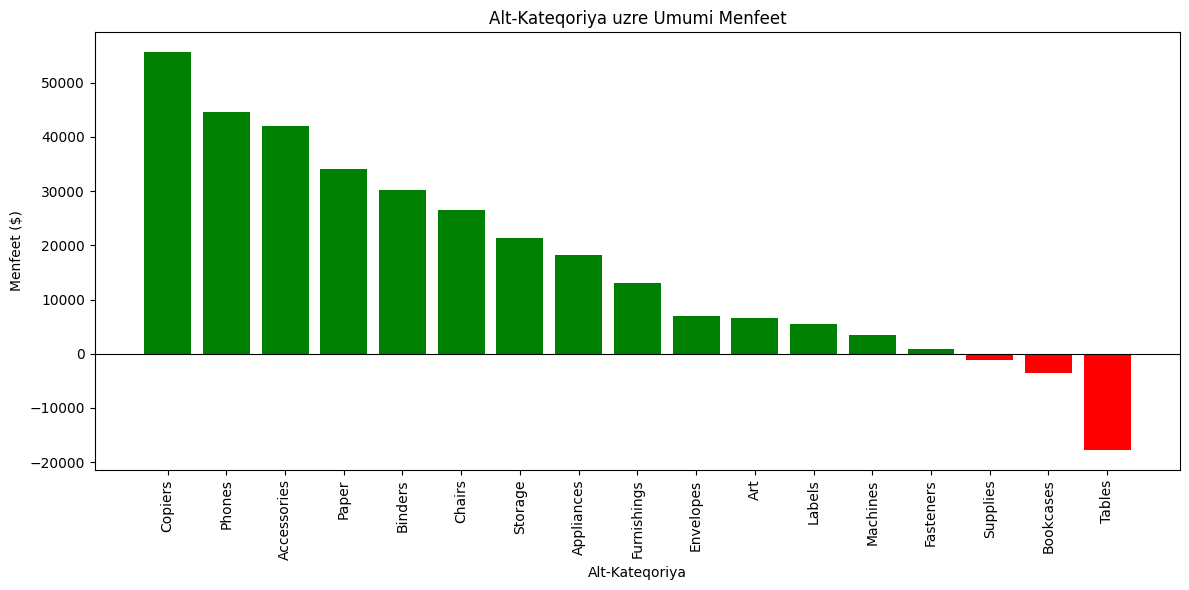

In [ ]:
alt_kat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print("EN COX QAZANC GETIREN 5 ALT-KATEQORIYA:")
print(alt_kat_profit.head(5))

print("\nEN AZ (VE YA MENFI) QAZANC GETIREN 5 ALT-KATEQORIYA:")
print(alt_kat_profit.tail(5))

plt.figure(figsize=(12, 6))
renkler = ['red' if x < 0 else 'green' for x in alt_kat_profit.values]
plt.bar(alt_kat_profit.index, alt_kat_profit.values, color=renkler)
plt.xticks(rotation=90)
plt.title('Alt-Kateqoriya uzre Umumi Menfeet')
plt.xlabel('Alt-Kateqoriya')
plt.ylabel('Menfeet ($)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

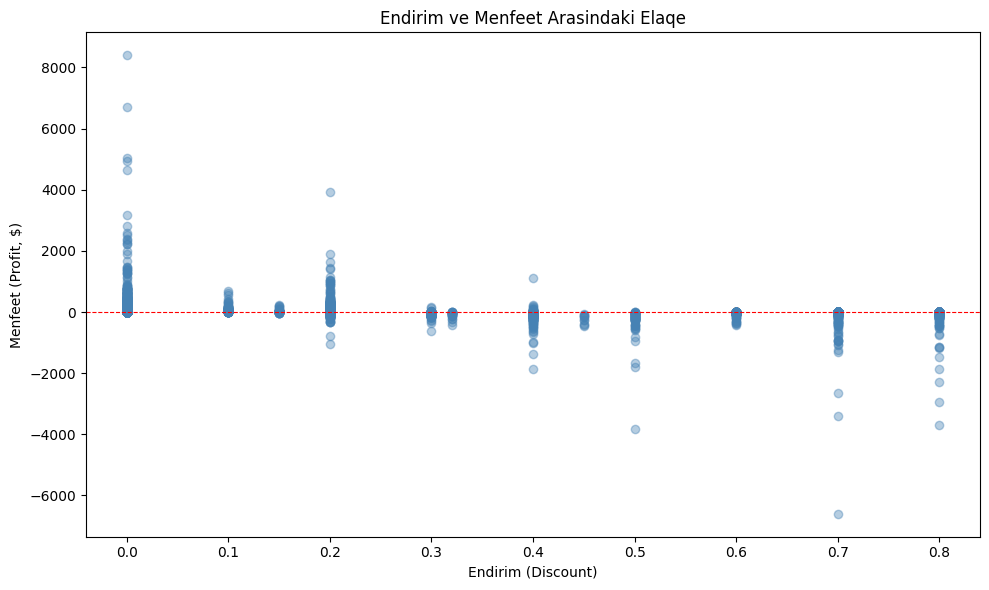

Endirimi 0.4-den boyuk olan sifarislerin ortalama menfeeti: -106.70802840300107
Endirimi 0.4-den kicik/beraber olan sifarislerin ortalama menfeeti: 42.59525573336277


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.4, color='steelblue')
plt.title('Endirim ve Menfeet Arasindaki Elaqe')
plt.xlabel('Endirim (Discount)')
plt.ylabel('Menfeet (Profit, $)')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

yuksek_endirim = df[df['Discount'] > 0.4]
print("Endirimi 0.4-den boyuk olan sifarislerin ortalama menfeeti:", yuksek_endirim['Profit'].mean())
print("Endirimi 0.4-den kicik/beraber olan sifarislerin ortalama menfeeti:", df[df['Discount'] <= 0.4]['Profit'].mean())

Illik Umumi Satis:
il
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Ildən-ilə artim faizi:
il
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


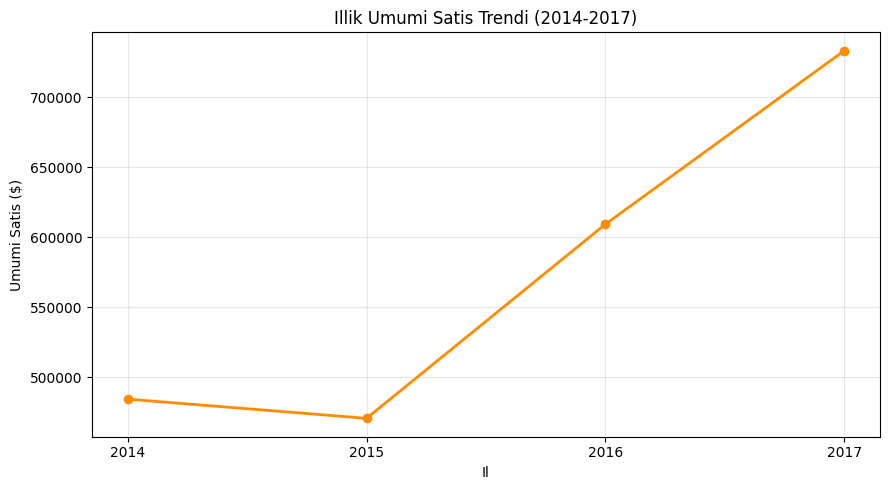

In [ ]:
df['il'] = df['Order Date'].dt.year

illik_satis = df.groupby('il')['Sales'].sum()
print("Illik Umumi Satis:")
print(illik_satis)

illik_artim = illik_satis.pct_change() * 100
print("\nIldən-ilə artim faizi:")
print(illik_artim)

plt.figure(figsize=(9, 5))
plt.plot(illik_satis.index, illik_satis.values, marker='o', color='darkorange', linewidth=2)
plt.title('Illik Umumi Satis Trendi (2014-2017)')
plt.xlabel('Il')
plt.ylabel('Umumi Satis ($)')
plt.xticks(illik_satis.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Kateqoriya uzre Menfeet Marjasi (%):
                       Sales       Profit  menfeet_marjasi
Category                                                  
Furniture        741999.7953   18451.2728         2.486695
Office Supplies  719047.0320  122490.8008        17.035158
Technology       836154.0330  145454.9481        17.395712


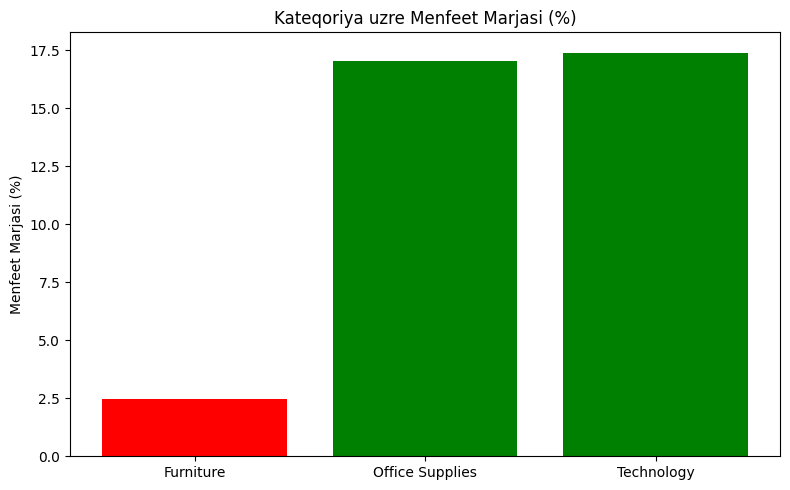

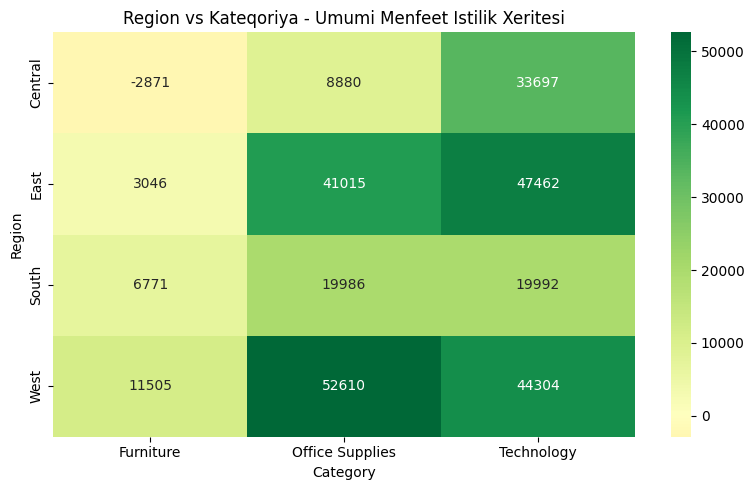

In [ ]:
kateqoriya_data = df.groupby('Category')[['Sales', 'Profit']].sum()
kateqoriya_data['menfeet_marjasi'] = (kateqoriya_data['Profit'] / kateqoriya_data['Sales']) * 100
print("Kateqoriya uzre Menfeet Marjasi (%):")
print(kateqoriya_data)

plt.figure(figsize=(8, 5))
renkler2 = ['red' if x < 10 else 'orange' if x < 15 else 'green' for x in kateqoriya_data['menfeet_marjasi']]
plt.bar(kateqoriya_data.index, kateqoriya_data['menfeet_marjasi'], color=renkler2)
plt.title('Kateqoriya uzre Menfeet Marjasi (%)')
plt.ylabel('Menfeet Marjasi (%)')
plt.tight_layout()
plt.show()

istilik_data = df.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='sum')
plt.figure(figsize=(8, 5))
sns.heatmap(istilik_data, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Region vs Kateqoriya - Umumi Menfeet Istilik Xeritesi')
plt.tight_layout()
plt.show()

Biznes Anlayislari

1. Tables alt-kateqoriyasi umumi olaraq 17725 dollar zerer edib, bunun esas sebebi 40 faizden yuxari endirimlerdir. Bu, Tables mehsullarina verilen endirimin 20-30 faiz ile mehdudlasdirilmasinin zeruri oldugunu gosterir.

2. Furniture kateqoriyasi 741999  dollar satisla ikinci en yuksek  satan   kateqoriyadir, amma menfeet marjasi cemi 2.5 faizdir (Office  Supplies ve Technology-de ise 17 faiz). Bu, yuksek satisin hemise yuksek qazanc demek olmadigini ve Furniture-in qiymetlendirme strategiyasinin yeniden nezerden kecirilmeli oldugunu gosterir.

3. West bolgesi Office Supplies-den 52610 dollar, East bolgesi ise Technology-den 47462 dollar qazanc elde edib - bunlar sirketin en guclu region-kateqoriya birlesmeleridir. Bu, marketinq ve stok resurslarinin bu iki bolgeye yoneldilmesinin umumi qazanci artira bileceyini gosterir.

4. 2016-2017 arasinda satis 20 faiz artib ve 2017-ci il tarixin en yaxsi ili olub (733215 dollar), bu artimda Technology kateqoriyasi hem en cox satan (836154 dollar), hem de en cox qazandiran (145454 dollar) kateqoriya kimi esas rol oynayib. Bu, gelecek strategiyada Technology mehsullarina ustunluk verilmesinin bu musbet trendi davam etdire bileceyini gosterir.